In [115]:
# LAB 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris


In [6]:
#Load data more than 2 dimensions
# Iris dataset has 4 dimensions
data = load_iris()
X = data.data
y = data.target

# import dataset using keras 
from keras.datasets import mnist
#(X_train, y_train), (X_test, y_test) = mnist.load_data()

c:\Anaconda\envs\opencv_env\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


In [7]:
#2. Find the 2 principal components using PCA from sklearn
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
print("Original shape:", X.shape)
print("Transformed shape:", X_pca.shape)

Original shape: (150, 4)
Transformed shape: (150, 2)


Original shape: (150, 4)
Transformed shape with 95% variance: (150, 2)


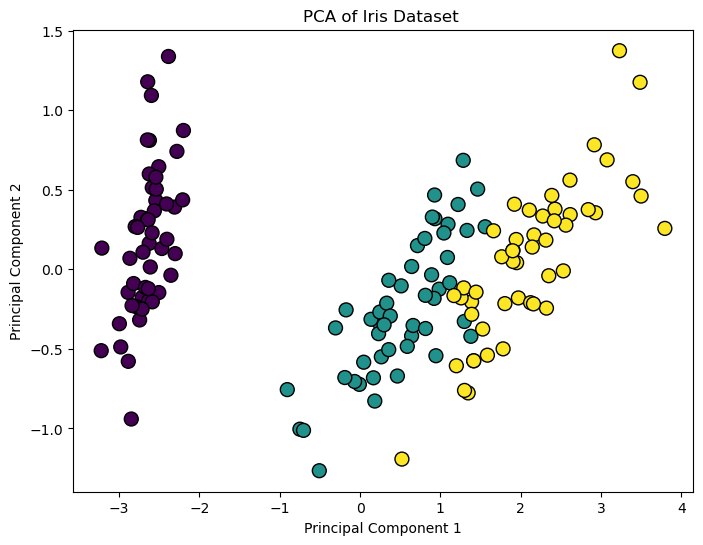

In [20]:
#3 Practice Using PCA to preserve variance
pca_95 = PCA(n_components=0.95) # Change the components to preserve desired variance
X_pca_95 = pca_95.fit_transform(X)
print("Original shape:", X.shape)
print("Transformed shape with 95% variance:", X_pca_95.shape)

 # Visualize the 2D PCA result
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca_95[:,0], X_pca_95[:,1], c=y,
                        cmap='viridis', edgecolor='k', s=100)
plt.title('PCA of Iris Dataset ')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

Accuracy with original data: 0.9333333333333333


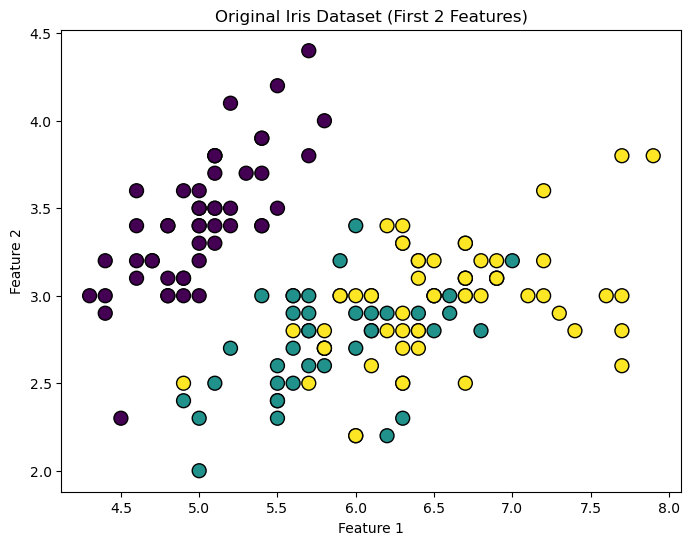

In [12]:
#4 Train a classification of regression neural network using: 
# a) Original data
# b) Principal components

# Original data
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
mlp_original = MLPClassifier(hidden_layer_sizes=(10,10), max_iter=1000, random_state=42)
mlp_original.fit(X_train, y_train)
accuracy_original = mlp_original.score(X_test, y_test)
print("Accuracy with original data:", accuracy_original)

# Visualize original data 
plt.figure(figsize=(8,6))
scatter = plt.scatter(X[:,0], X[:,1], c=y,
                        cmap='viridis', edgecolor='k', s=100)
plt.title('Original Iris Dataset (First 2 Features)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [ ]:
# PCA without using sklearn
def pca_manual(X, n_components):
    # Center the data
    X_centered = X - np.mean(X, axis=0)
    
    # Compute covariance matrix
    covariance_matrix = np.cov(X_centered, rowvar=False) # sklearn uses rowvar=False by default
    
    # Eigen decomposition
    eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix) # sklearn uses svd decomposition but eigh is fine here for covariance matrix
    
    # Sort eigenvalues and eigenvectors
    sorted_indices = np.argsort(eigenvalues)[::-1]  # Descending order here, sklearn order by variance
    sorted_eigenvectors = eigenvectors[:, sorted_indices]
    
    # Select top n_components
    selected_eigenvectors = sorted_eigenvectors[:, :n_components]
    
    # Transform data
    X_reduced = np.dot(X_centered, selected_eigenvectors) # eqivalent to pca.fit_transform(X) in sklearn
    
    return X_reduced

Accuracy with PCA reduced data: 0.9666666666666667


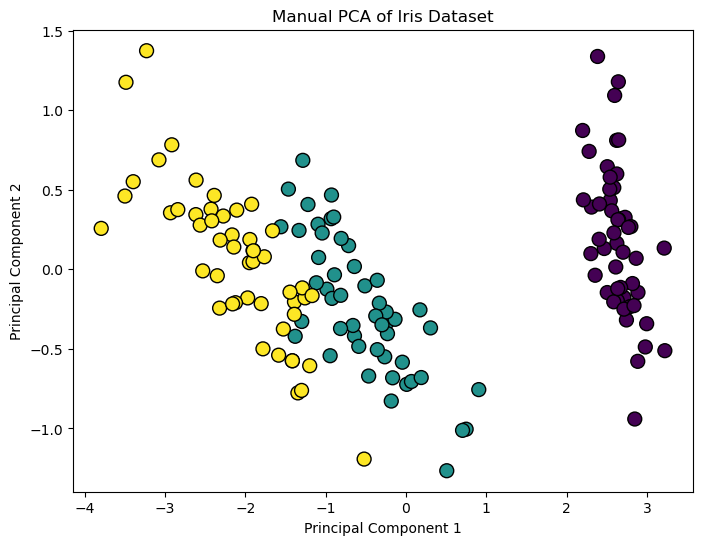

In [30]:
# use manual PCA and visualize
X_pca_manual = pca_manual(X, n_components=2)
X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca_manual, y, test_size=0.2, random_state=42)
mlp_pca = MLPClassifier(hidden_layer_sizes=(10,10), max_iter=1000, random_state=42)
mlp_pca.fit(X_train_pca, y_train)
accuracy_pca = mlp_pca.score(X_test_pca, y_test)
print("Accuracy with PCA reduced data:", accuracy_pca)

# Visualize PCA manual result
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca_manual[:,0], X_pca_manual[:,1], c=y, cmap='viridis', edgecolor='k', s=100)
plt.title('Manual PCA of Iris Dataset')
plt.xlabel('Principal Component 1') 
plt.ylabel('Principal Component 2')
plt.show()

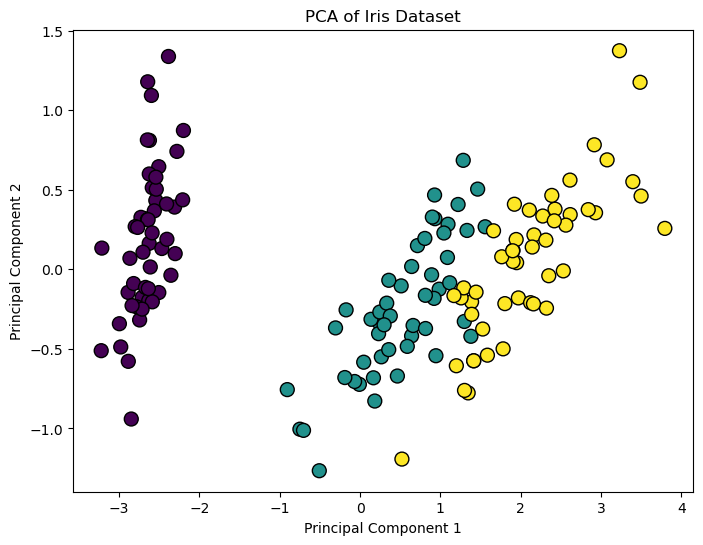

Accuracy with original data: 0.93
Accuracy with PCA data: 0.97


In [14]:
# Princiapll components using sklearn PCA
X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)
mlp_pca = MLPClassifier(hidden_layer_sizes=(10,10), max_iter=1000, random_state=42)
mlp_pca.fit(X_train_pca, y_train)
accuracy_pca = mlp_pca.score(X_test_pca, y_test)
#print("Accuracy with PCA data:", accuracy_pca)

# Visualize PCA data
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=y,
                        cmap='viridis', edgecolor='k', s=100)
plt.title('PCA of Iris Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

#5 Compare the results and discuss
print(f"Accuracy with original data: {accuracy_original:.2f}")
print(f"Accuracy with PCA data: {accuracy_pca:.2f}")

# The accuracy may vary based on the random state and model parameters.
# In this case, we can see how dimensionality reduction via PCA affects the performance of a neural network classifier.

Accuracy with Kernel PCA (linear kernel): 0.97


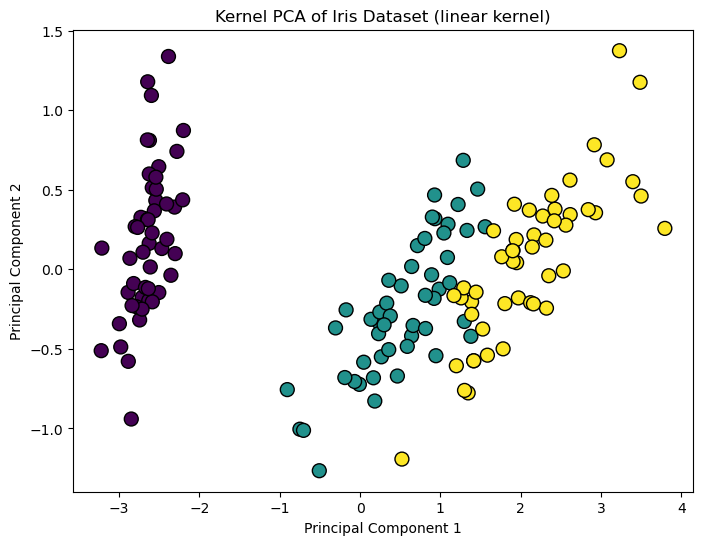

Accuracy with Kernel PCA (sigmoid kernel): 0.37


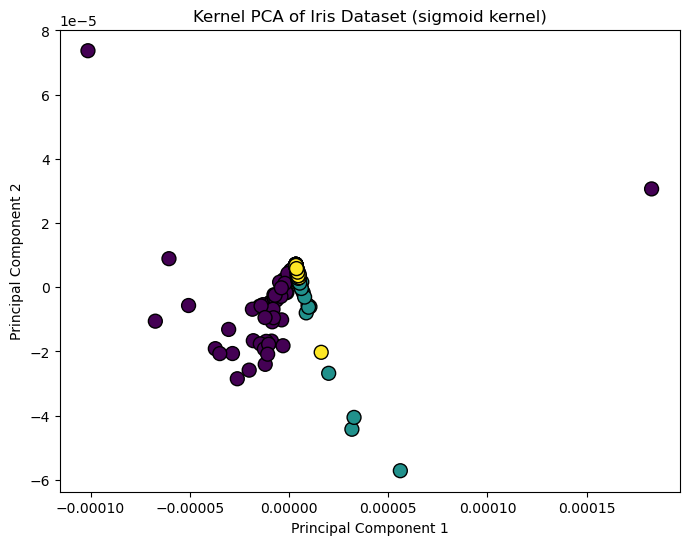

Accuracy with Kernel PCA (rbf kernel): 0.97


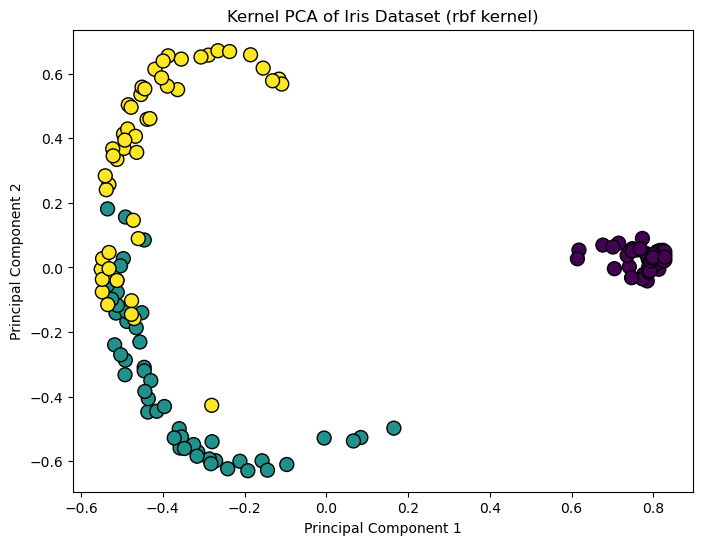

In [122]:
# Repeat part 4 using Kernel PCA with different kernels (linear, polynomial, RBF). 
from sklearn.decomposition import KernelPCA
kernels = ['linear', 'sigmoid', 'rbf']
for kernel in kernels:
    kpca = KernelPCA(n_components=2, kernel=kernel)
    X_kpca = kpca.fit_transform(X)
    
    X_train_kpca, X_test_kpca, y_train, y_test = train_test_split(X_kpca, y, test_size=0.2, random_state=42)
    mlp_kpca = MLPClassifier(hidden_layer_sizes=(10,10), max_iter=1000, random_state=42)
    mlp_kpca.fit(X_train_kpca, y_train)
    accuracy_kpca = mlp_kpca.score(X_test_kpca, y_test)
    
    print(f"Accuracy with Kernel PCA ({kernel} kernel): {accuracy_kpca:.2f}")
    
    # Visualize Kernel PCA data
    plt.figure(figsize=(8,6))
    scatter = plt.scatter(X_kpca[:,0], X_kpca[:,1], c=y,
                            cmap='viridis', edgecolor='k', s=100)
    plt.title(f'Kernel PCA of Iris Dataset ({kernel} kernel)')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.show()

In [123]:
# 6- Build a pipeline to tune the hyperparameters of Kernel PCA and also the neural network. 
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import KernelPCA
from sklearn.neural_network import MLPClassifier

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kpca', KernelPCA(fit_inverse_transform=False)),
    ('mlp', MLPClassifier(
        max_iter=1000,
        early_stopping=True,
        n_iter_no_change=10,
        random_state=42
    ))
])

param_grid = {
    # Kernel PCA
    'kpca__n_components': [1, 2, 3],
    'kpca__kernel': ['linear', 'rbf', 'sigmoid'],
    'kpca__gamma': [0.01, 0.1, 1],  # needed for rbf & sigmoid

    # MLP
    'mlp__hidden_layer_sizes': [(5,), (10, 10), (20, 10)],
    'mlp__alpha': [0.0001, 0.001, 0.01]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X, y)

print("Best parameters found:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)


#Which hyperparameters can be tuned?
# Hyperparameters that can be tuned include:
# - Number of components in Kernel PCA
# - Kernel type in Kernel PCA (linear, polynomial, RBF, sigmoid)
# - Gamma parameter in Kernel PCA (for RBF and sigmoid kernels)
# MLP Classifier:
# - Hidden layer sizes in the neural network
# - Regularization parameter (alpha) in the neural network


Best parameters found: {'kpca__gamma': 0.01, 'kpca__kernel': 'linear', 'kpca__n_components': 2, 'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (5,)}
Best cross-validation score: 0.6399999999999999


Classification problem
1-

3- Tune the hyperparameters (including hidden layer size and activation functions). What else can be tuned?
4- Plot the loss and accuracy for training and testing datasets.
5- Save the weights of the layers and use callbacks during the training process.
6- Practice saving and loading the trained model.

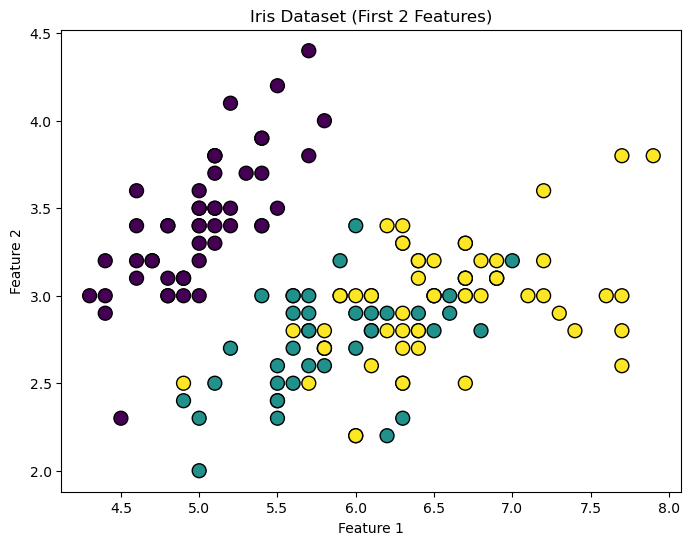

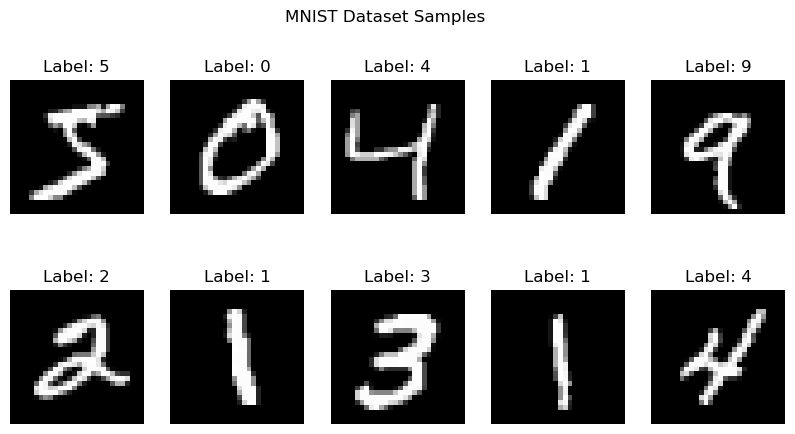

In [124]:
# Load IRIS and MNIST datasets from the Keras 
from sklearn.datasets import fetch_openml
iris = fetch_openml(name='iris', version=1)
mnist = fetch_openml(name='mnist_784', version=1)
# iris data
X_iris = iris.data
y_iris = iris.target
# mnist data
X_mnist = mnist.data
y_mnist = mnist.target

# Visualize some samples from both datasets
# Iris dataset
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_iris.iloc[:,0], X_iris.iloc[:,1], c=y_iris.astype('category').cat.codes,
                        cmap='viridis', edgecolor='k', s=100)
plt.title('Iris Dataset (First 2 Features)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

# MNIST dataset
fig, axes = plt.subplots(2, 5, figsize=(10,5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_mnist.iloc[i].values.reshape(28, 28), cmap='gray')
    ax.set_title(f'Label: {y_mnist.iloc[i]}')
    ax.axis('off')
plt.suptitle('MNIST Dataset Samples')
plt.show()



In [125]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_iris_encoded = le.fit_transform(y_iris)
y_iris = y_iris_encoded

# Train-test split
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)

# Ensure numeric
X_train_iris = X_train_iris.apply(pd.to_numeric, errors='coerce')
X_test_iris = X_test_iris.apply(pd.to_numeric, errors='coerce')

X_train_iris = X_train_iris.replace([np.inf, -np.inf], np.nan)
X_test_iris = X_test_iris.replace([np.inf, -np.inf], np.nan)

X_train_iris = X_train_iris.fillna(X_train_iris.mean())
X_test_iris = X_test_iris.fillna(X_train_iris.mean())

# Scale features
scaler_iris = StandardScaler()
X_train_iris = scaler_iris.fit_transform(X_train_iris)
X_test_iris = scaler_iris.transform(X_test_iris)

# Fine tune MLP hyperparameters for Iris dataset
pipeline_iris = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        max_iter=10000,
        early_stopping=True,
        n_iter_no_change=10,
        random_state=42
    ))
])
param_grid_iris = {
    'mlp__hidden_layer_sizes': [(10, 10),(100, 100), (200, 200), (600, 600)],
    'mlp__activation': ['relu', 'tanh', 'logistic', 'identity'],
    'mlp__alpha': [0.0001, 0.001, 0.01, 0.1], 
}
cv_iris = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
grid_search_iris = GridSearchCV(
    pipeline_iris,
    param_grid_iris,
    cv=cv_iris,
    scoring='accuracy',
    n_jobs=-1
)
grid_search_iris.fit(X_iris, y_iris)
print("Best parameters for Iris dataset:", grid_search_iris.best_params_)
print("Best cross-validation score for Iris dataset:", grid_search_iris.best_score_)



Best parameters for Iris dataset: {'mlp__activation': 'identity', 'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (600, 600)}
Best cross-validation score for Iris dataset: 0.9066666666666666


In [131]:
# Train MLP
# We can use previous model hyperparameters found from grid search, but to test with different settings trying new model
mlp_iris = MLPClassifier(
    hidden_layer_sizes=(550, 550), # Should experiment with more values 
    max_iter=300,
    early_stopping=True,
    n_iter_no_change=10,
    alpha=0.001,
    activation='relu', # Change activation to others like 'tanh', 'relu', sigmoid
    random_state=42
)
# FORCE numeric NumPy arrays
X_train_iris = np.asarray(X_train_iris, dtype=np.float64)
X_test_iris  = np.asarray(X_test_iris, dtype=np.float64)

y_train_iris = np.asarray(y_train_iris, dtype=np.int64)
y_test_iris  = np.asarray(y_test_iris, dtype=np.int64)


mlp_iris.fit(X_train_iris, y_train_iris)

accuracy_iris = mlp_iris.score(X_test_iris, y_test_iris)
print("Iris Dataset Accuracy:", accuracy_iris)

Iris Dataset Accuracy: 0.8666666666666667


In [135]:
"""# manual validation loop without early stopping
from sklearn.metrics import accuracy_score

mlp = MLPClassifier(
    hidden_layer_sizes=(10, 10),
    max_iter=1,          # ONE iteration at a time
    warm_start=True,     # keep weights
    random_state=42
)

train_losses = []
val_accuracies = []

for i in range(500):
    mlp.fit(X_train_iris, y_train_iris)
    
    # Record training loss
    train_losses.append(mlp.loss_)
    
    # Record validation accuracy
    y_val_pred = mlp.predict(X_test_iris)
    val_accuracies.append(accuracy_score(y_test_iris, y_val_pred))

    #print(f"Iteration {i+1}, Training Loss: {mlp.loss_:.4f}, Validation Accuracy: {val_accuracies[-1]:.4f}")

# Plot training loss and validation accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Training Loss over Iterations')
plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Validation Accuracy', color='orange')
plt.xlabel('Iterations')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy over Iterations')
plt.show()""" 


'# manual validation loop without early stopping\nfrom sklearn.metrics import accuracy_score\n\nmlp = MLPClassifier(\n    hidden_layer_sizes=(10, 10),\n    max_iter=1,          # ONE iteration at a time\n    warm_start=True,     # keep weights\n    random_state=42\n)\n\ntrain_losses = []\nval_accuracies = []\n\nfor i in range(500):\n    mlp.fit(X_train_iris, y_train_iris)\n\n    # Record training loss\n    train_losses.append(mlp.loss_)\n\n    # Record validation accuracy\n    y_val_pred = mlp.predict(X_test_iris)\n    val_accuracies.append(accuracy_score(y_test_iris, y_val_pred))\n\n    #print(f"Iteration {i+1}, Training Loss: {mlp.loss_:.4f}, Validation Accuracy: {val_accuracies[-1]:.4f}")\n\n# Plot training loss and validation accuracy\nplt.figure(figsize=(12, 5))\nplt.subplot(1, 2, 1)\nplt.plot(train_losses, label=\'Training Loss\')\nplt.xlabel(\'Iterations\')\nplt.ylabel(\'Loss\')\nplt.title(\'Training Loss over Iterations\')\nplt.subplot(1, 2, 2)\nplt.plot(val_accuracies, label=\

In [128]:
# MNIST dataset

le = LabelEncoder()
y_mnist_encoded = le.fit_transform(y_mnist)
y_mnist = y_mnist_encoded
X_train_mnist, X_test_mnist, y_train_mnist, y_test_mnist = train_test_split(
    X_mnist, y_mnist, test_size=0.2, random_state=42, stratify=y_mnist
)
# Scale features
scaler_mnist = StandardScaler()
X_train_mnist = scaler_mnist.fit_transform(X_train_mnist)
X_test_mnist = scaler_mnist.transform(X_test_mnist)
# Train MLP
mlp_mnist = MLPClassifier(
    hidden_layer_sizes=(60, 60),
    max_iter=10000,
    early_stopping=True,
    n_iter_no_change=15,
    activation='relu',
    random_state=42
)
mlp_mnist.fit(X_train_mnist, y_train_mnist)
accuracy_mnist = mlp_mnist.score(X_test_mnist, y_test_mnist)
print("MNIST Dataset Accuracy:", accuracy_mnist)


MNIST Dataset Accuracy: 0.9713571428571428


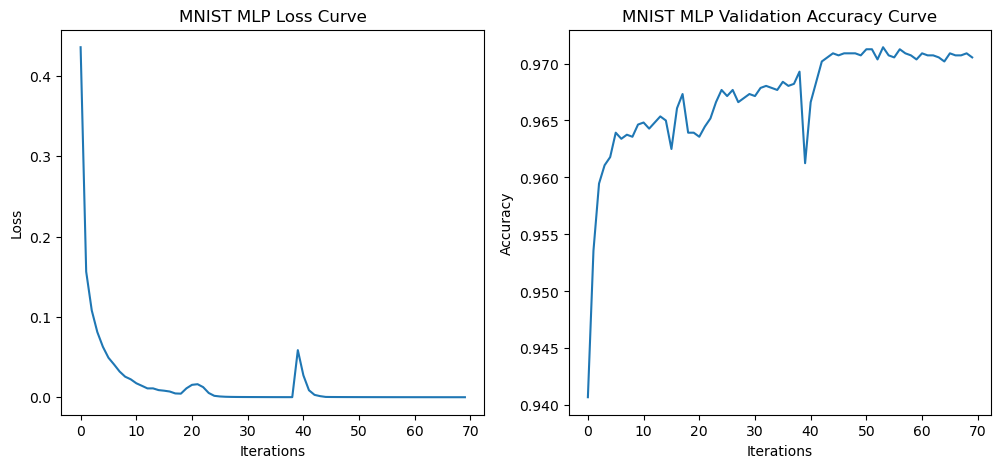

In [129]:
# Plot loss and accuracy curves for MNIST
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(mlp_mnist.loss_curve_)
plt.title('MNIST MLP Loss Curve')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.subplot(1, 2, 2)
plt.plot(mlp_mnist.validation_scores_)
plt.title('MNIST MLP Validation Accuracy Curve')
plt.xlabel('Iterations')
plt.ylabel('Accuracy')
plt.show()

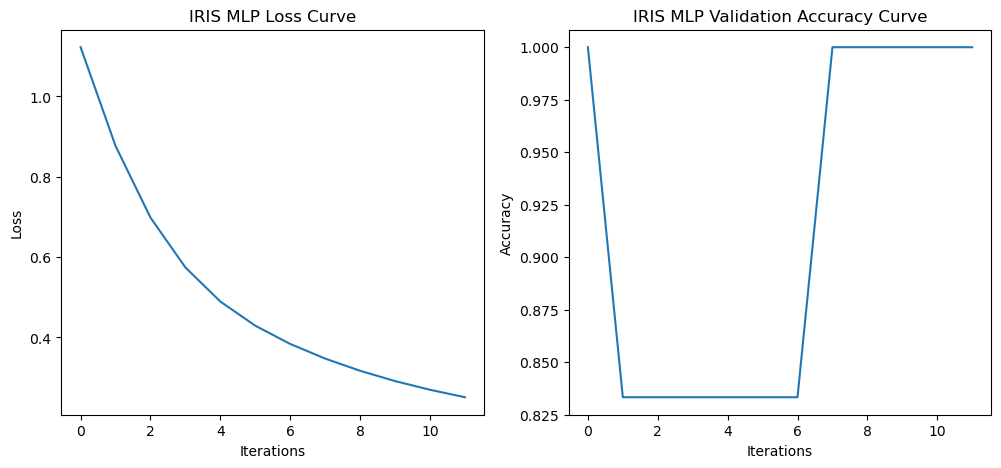

Iris Dataset - Test Accuracy: 0.8667, Validation Accuracy: 1.0000
MNIST Dataset - Test Accuracy: 0.9714, Validation Accuracy: 0.9705


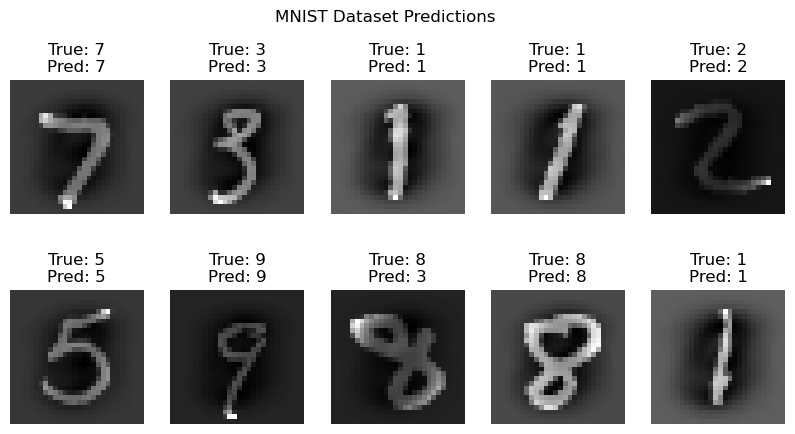

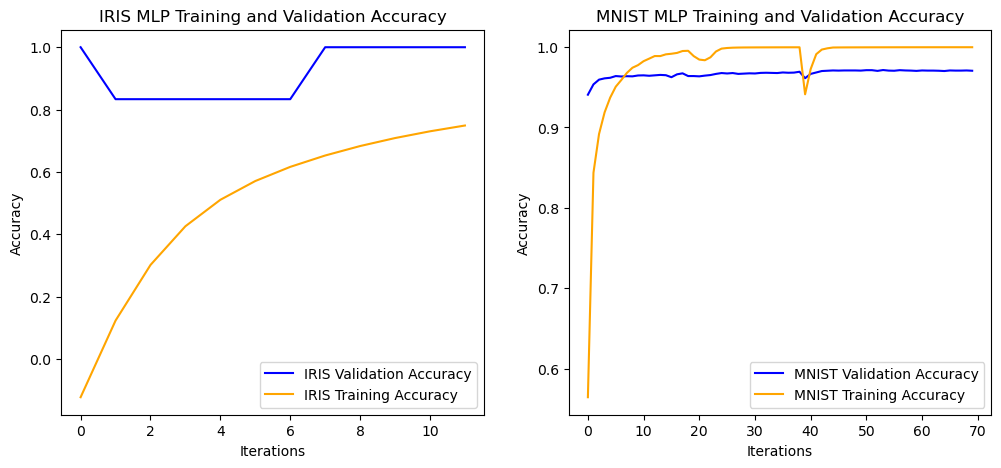

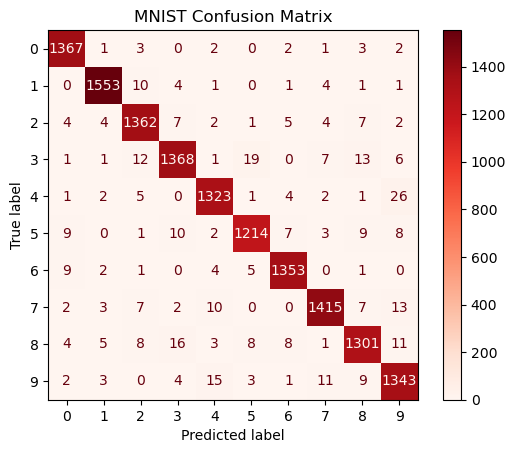

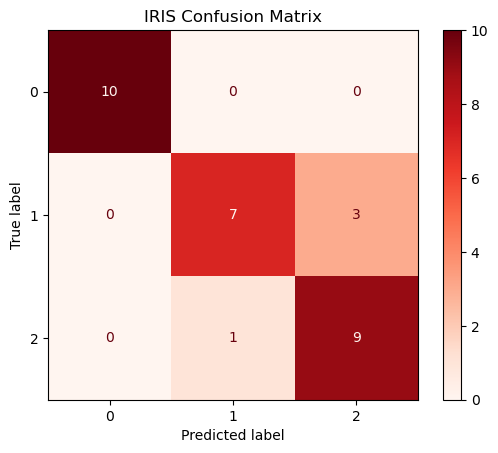

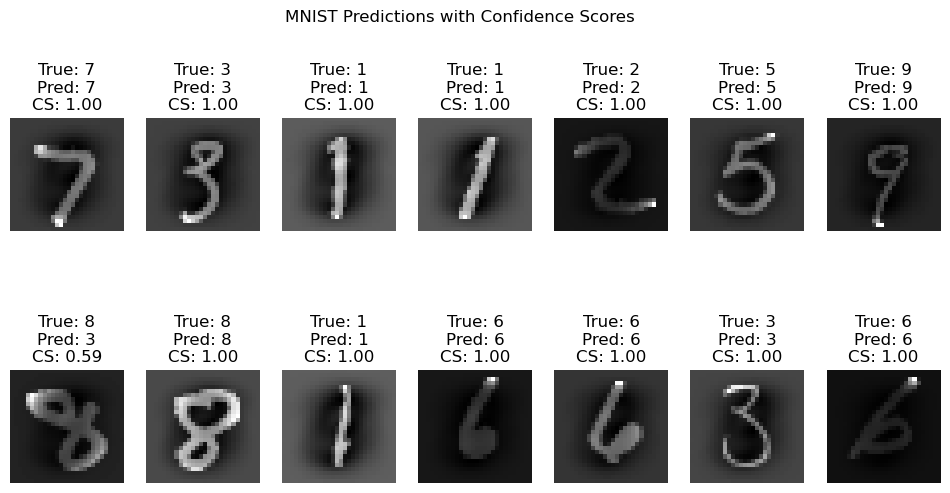

In [158]:
# Plot Loss and accuracy curves for IRIS with early stopping
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(mlp_iris.loss_curve_)
plt.title('IRIS MLP Loss Curve')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.subplot(1, 2, 2)
plt.plot(mlp_iris.validation_scores_)
plt.title('IRIS MLP Validation Accuracy Curve')
plt.xlabel('Iterations')
plt.ylabel('Accuracy')
plt.show()

# Comare test and validation accuracies
print(f"Iris Dataset - Test Accuracy: {accuracy_iris:.4f}, Validation Accuracy: {mlp_iris.validation_scores_[-1]:.4f}")
print(f"MNIST Dataset - Test Accuracy: {accuracy_mnist:.4f}, Validation Accuracy: {mlp_mnist.validation_scores_[-1]:.4f}")

# visualixe some predictions on MNIST
y_mnist_pred = mlp_mnist.predict(X_test_mnist)
fig, axes = plt.subplots(2, 5, figsize=(10,5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test_mnist[i].reshape(28, 28), cmap='gray')
    ax.set_title(f'True: {y_test_mnist[i]}\nPred: {y_mnist_pred[i]}')
    ax.axis('off')
plt.suptitle('MNIST Dataset Predictions')
plt.show()


# Visualize training accuracy and validation accuracy curves for IRIS and MNIST datasets
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(mlp_iris.validation_scores_, label='IRIS Validation Accuracy', color='blue')
plt.plot([1 - loss for loss in mlp_iris.loss_curve_], label='IRIS Training Accuracy', color='orange')
plt.xlabel('Iterations')
plt.ylabel('Accuracy')
plt.title('IRIS MLP Training and Validation Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(mlp_mnist.validation_scores_, label='MNIST Validation Accuracy', color='blue')
plt.plot([1 - loss for loss in mlp_mnist.loss_curve_], label='MNIST Training Accuracy', color='orange')
plt.xlabel('Iterations')
plt.ylabel('Accuracy')
plt.title('MNIST MLP Training and Validation Accuracy')
plt.legend()
plt.show()

# visualize confusion matrix for MNIST
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test_mnist, y_mnist_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=mlp_mnist.classes_)
disp.plot(cmap=plt.cm.Reds)
plt.title('MNIST Confusion Matrix')
plt.show()

# Visualize confusion matrix for IRIS
y_iris_pred = mlp_iris.predict(X_test_iris)
cm_iris = confusion_matrix(y_test_iris, y_iris_pred)
disp_iris = ConfusionMatrixDisplay(confusion_matrix=cm_iris, display_labels=mlp_iris.classes_)
disp_iris.plot(cmap=plt.cm.Reds)
plt.title('IRIS Confusion Matrix')
plt.show()

# Visualize 10 predictions on MNIST with confidence scores
y_mnist_proba = mlp_mnist.predict_proba(X_test_mnist)
fig, axes = plt.subplots(2, 7, figsize=(12,6))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test_mnist[i].reshape(28, 28), cmap='gray')
    true_label = y_test_mnist[i]
    pred_label = y_mnist_pred[i]
    confidence = np.max(y_mnist_proba[i])
    ax.set_title(f'True: {true_label}\nPred: {pred_label}\nCS: {confidence:.2f}')
    ax.axis('off')
plt.suptitle('MNIST Predictions with Confidence Scores')
plt.show()